In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/hotel_bookings.csv")
df.head()

,hotel,is_canceled,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time
0,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,C,3,No Deposit,0,0.0,0,0,Check-Out,01-07-2015,342
1,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,C,4,No Deposit,0,0.0,0,0,Check-Out,01-07-2015,737
2,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Direct,...,C,0,No Deposit,0,75.0,0,0,Check-Out,02-07-2015,7
3,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Corporate,...,A,0,No Deposit,0,75.0,0,0,Check-Out,02-07-2015,13
4,Resort Hotel,0,2015,July,0,2,2,0.0,GBR,Online TA,...,A,0,No Deposit,0,98.0,0,1,Check-Out,03-07-2015,14


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   arrival_date_year               119390 non-null  int64  
 3   arrival_date_month              119390 non-null  str    
 4   stays_in_weekend_nights         119390 non-null  int64  
 5   stays_in_week_nights            119390 non-null  int64  
 6   adults                          119390 non-null  int64  
 7   children                        119386 non-null  float64
 8   country                         118902 non-null  str    
 9   market_segment                  119390 non-null  str    
 10  is_repeated_guest               119390 non-null  int64  
 11  previous_cancellations          119390 non-null  int64  
 12  previous_bookings_not_cance

In [4]:
df.shape

(119390, 24)

In [5]:
df.isnull().sum()

hotel                               0
is_canceled                         0
arrival_date_year                   0
arrival_date_month                  0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            4
country                           488
market_segment                      0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
adr                                 0
required_car_parking_spaces         0
total_of_special_requests           0
reservation_status                  0
reservation_status_date             0
lead_time                           0
dtype: int64

In [6]:
(df.isnull().sum()/len(df))*100

hotel                             0.000000
is_canceled                       0.000000
arrival_date_year                 0.000000
arrival_date_month                0.000000
stays_in_weekend_nights           0.000000
stays_in_week_nights              0.000000
adults                            0.000000
children                          0.003350
country                           0.408744
market_segment                    0.000000
is_repeated_guest                 0.000000
previous_cancellations            0.000000
previous_bookings_not_canceled    0.000000
reserved_room_type                0.000000
assigned_room_type                0.000000
booking_changes                   0.000000
deposit_type                      0.000000
days_in_waiting_list              0.000000
adr                               0.000000
required_car_parking_spaces       0.000000
total_of_special_requests         0.000000
reservation_status                0.000000
reservation_status_date           0.000000
lead_time  

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

hotel                             0
is_canceled                       0
arrival_date_year                 0
arrival_date_month                0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
country                           0
market_segment                    0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status                0
reservation_status_date           0
lead_time                         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(32171)

In [10]:
df=df.drop_duplicates()

In [11]:
df.shape

(86727, 24)

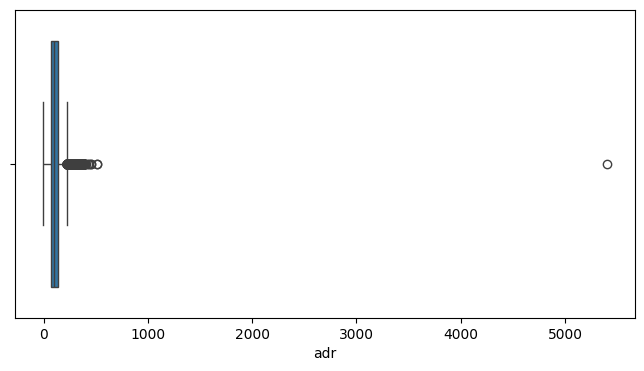

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['adr'])

plt.show()

In [13]:
Q1=df['adr'].quantile(0.25)

Q3=df['adr'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

In [14]:
outliers=df[(df['adr']<lower)|
            (df['adr']>upper)]

len(outliers)

2503

In [15]:
df=df[(df['adr']>=lower)&
      (df['adr']<=upper)]

In [16]:
df['total_nights']=(
    df['stays_in_weekend_nights']
    +
    df['stays_in_week_nights']
)

In [17]:
df['total_guests']=(
    df['adults']
    +
    df['children']
)

In [18]:
df['planner_type'] = np.where(
    df['lead_time'] > 60,
    'Early Planner',
    'Late Planner'
)

In [19]:
def planner(x):
    if x <= 7:
        return 'Last Minute'
    elif x <= 60:
        return 'Medium Planner'
    else:
        return 'Early Planner'

df['planner_type'] = df['lead_time'].apply(planner)

In [20]:
summer = ['June','July','August']
winter = ['December','January','February']
spring = ['March','April','May']

def season(month):
    if month in summer:
        return 'Summer'
    elif month in winter:
        return 'Winter'
    elif month in spring:
        return 'Spring'
    else:
        return 'Autumn'

df['season'] = df['arrival_date_month'].apply(season)

In [21]:
print(df.columns.tolist())

['hotel', 'is_canceled', 'arrival_date_year', 'arrival_date_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'country', 'market_segment', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'lead_time', 'total_nights', 'total_guests', 'planner_type', 'season']


In [22]:
df.head()

,hotel,is_canceled,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time,total_nights,total_guests,planner_type,season
0,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,0.0,0,0,Check-Out,01-07-2015,342,0,2.0,Early Planner,Summer
1,Resort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,...,0.0,0,0,Check-Out,01-07-2015,737,0,2.0,Early Planner,Summer
2,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Direct,...,75.0,0,0,Check-Out,02-07-2015,7,1,1.0,Last Minute,Summer
3,Resort Hotel,0,2015,July,0,1,1,0.0,GBR,Corporate,...,75.0,0,0,Check-Out,02-07-2015,13,1,1.0,Medium Planner,Summer
4,Resort Hotel,0,2015,July,0,2,2,0.0,GBR,Online TA,...,98.0,0,1,Check-Out,03-07-2015,14,2,2.0,Medium Planner,Summer


In [23]:
df.head().to_csv(index=False)

'hotel,is_canceled,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,country,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,lead_time,total_nights,total_guests,planner_type,season\r\nResort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,0,0,0,C,C,3,No Deposit,0,0.0,0,0,Check-Out,01-07-2015,342,0,2.0,Early Planner,Summer\r\nResort Hotel,0,2015,July,0,0,2,0.0,PRT,Direct,0,0,0,C,C,4,No Deposit,0,0.0,0,0,Check-Out,01-07-2015,737,0,2.0,Early Planner,Summer\r\nResort Hotel,0,2015,July,0,1,1,0.0,GBR,Direct,0,0,0,A,C,0,No Deposit,0,75.0,0,0,Check-Out,02-07-2015,7,1,1.0,Last Minute,Summer\r\nResort Hotel,0,2015,July,0,1,1,0.0,GBR,Corporate,0,0,0,A,A,0,No Deposit,0,75.0,0,0,Check-Out,02-07-2015,13,1,1.0,Medium Planner,Summer\r\nRes

In [24]:
df.to_csv(
    "../data/hotel_bookings_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)